In [ ]:
!wget https://cdn.talentsprint.com/aiml/Experiment_related_data/diabetes.csv

--2026-08-01 05:31:26--  https://cdn.talentsprint.com/aiml/Experiment_related_data/diabetes.csv
Resolving cdn.talentsprint.com (cdn.talentsprint.com)... 172.105.34.236
Connecting to cdn.talentsprint.com (cdn.talentsprint.com)|172.105.34.236|:443... connected.
HTTP request sent, awaiting response... 302 Moved Temporarily
Location: https://cdn.ap-south-1.linodeobjects.com/public_html/aiml/Experiment_related_data/diabetes.csv [following]
--2026-08-01 05:31:27--  https://cdn.ap-south-1.linodeobjects.com/public_html/aiml/Experiment_related_data/diabetes.csv
Resolving cdn.ap-south-1.linodeobjects.com (cdn.ap-south-1.linodeobjects.com)... 172.104.188.75, 139.162.58.169, 172.104.188.11, ...
Connecting to cdn.ap-south-1.linodeobjects.com (cdn.ap-south-1.linodeobjects.com)|172.104.188.75|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23873 (23K) [text/csv]
Saving to: ‘diabetes.csv’

diabetes.csv        100%[===================>]  23.31K   147KB/s    in 0.2s    

2026-0

In [ ]:
import pandas as pd

# Load the data
file_path = 'diabetes.csv'
data = pd.read_csv(file_path)

# Display the first few rows of the data
data.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Features
X = data.drop(columns=['Outcome', 'BMI'])

# Classification target
y_classification = data['Outcome']

# Regression target (BMI)
y_regression = data['BMI']


In [ ]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Input layer
input_layer = Input(shape=(7,))

# Hidden layers
l1 = Dense(8, activation='relu')(input_layer)
l2 = Dense(10, activation='relu')(l1)
l3 = Dense(10, activation='relu')(l2)

# Output 1: Classification
output_1 = Dense(1, activation='sigmoid', name='classification_output')(l3)

# Output 2: Regression (BMI)
output_2 = Dense(1, activation='linear', name='regression_output')(l3)

# Define the model
model = Model(inputs=input_layer, outputs=[output_1, output_2])

# Compile the model
model.compile(optimizer='adam',
              loss={'classification_output': 'binary_crossentropy',
                    'regression_output': 'mse'},
              metrics={'classification_output': 'accuracy', 'regression_output': 'mae'})

# Display the model summary
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 8)         │         64 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 10)        │         90 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 10)        │        110 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification_out… │ (None, 1)         │         11 │ dense_5[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regression_output   │ (None, 1)         │         11 │ dense_5[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 286 (1.12 KB)

 Trainable params: 286 (1.12 KB)

 Non-trainable params: 0 (0.00 B)

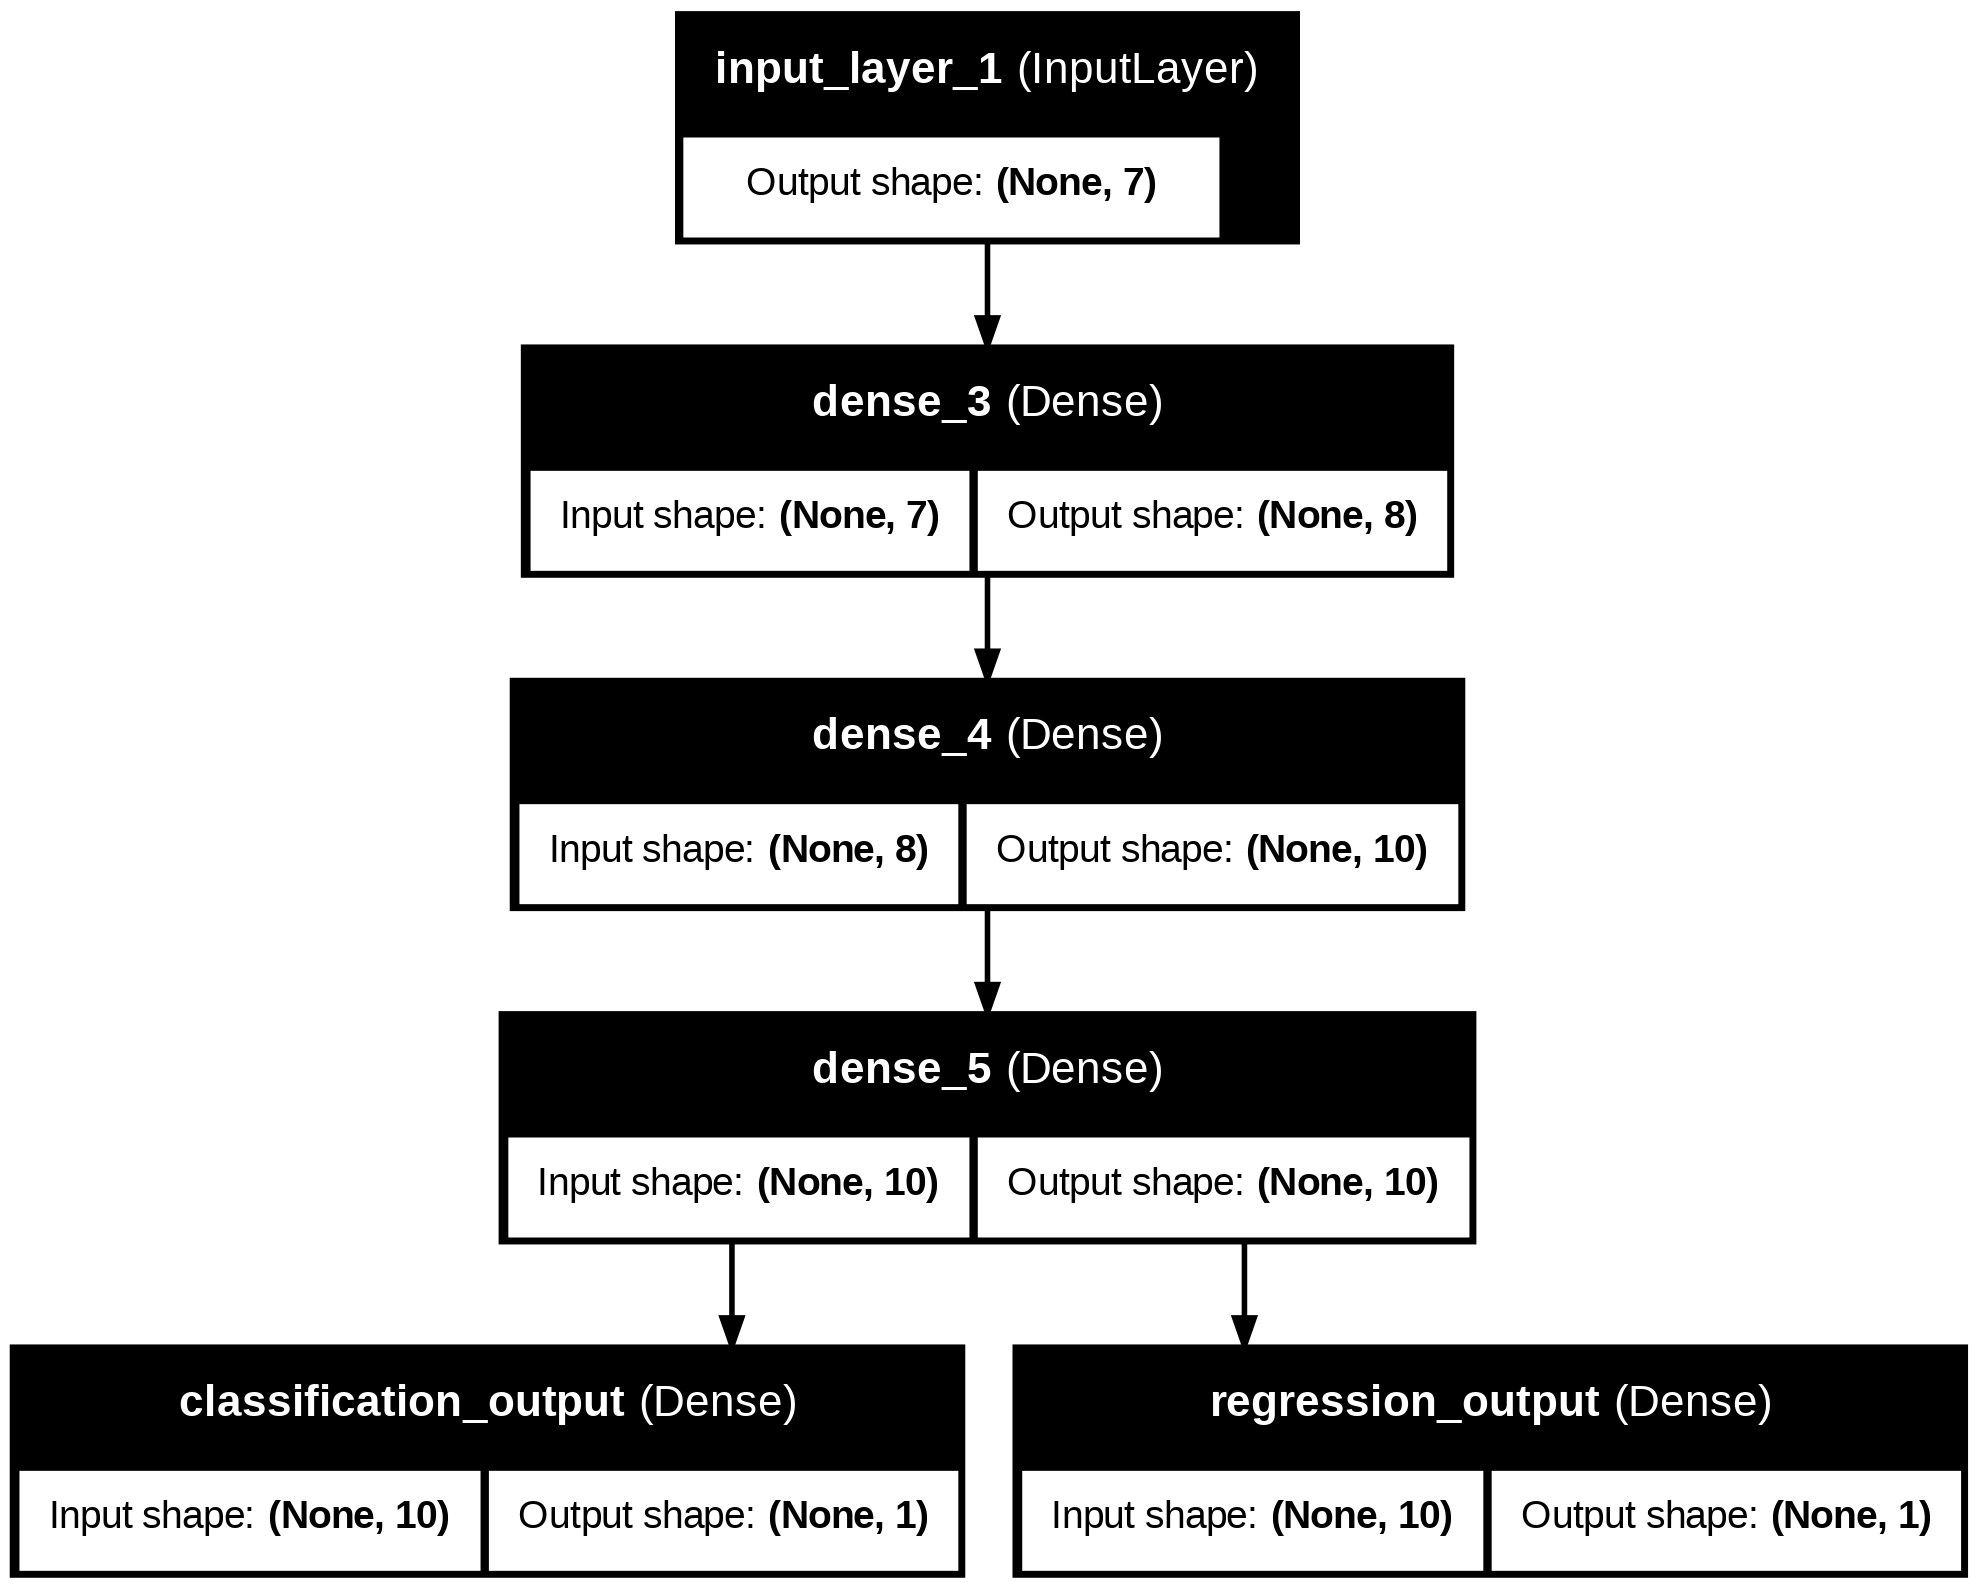

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model_with_two_predictions.png', show_shapes=True, show_layer_names=True)

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_classification, y_regression, test_size=0.2, random_state=42)

# Train the model
history = model.fit(X_train,
                    {'classification_output': y_class_train, 'regression_output': y_reg_train},
                    validation_data=(X_test, {'classification_output': y_class_test, 'regression_output': y_reg_test}),
                    epochs=50, batch_size=32)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - classification_output_accuracy: 0.3469 - classification_output_loss: 12.7500 - loss: 436.9743 - regression_output_loss: 414.0761 - regression_output_mae: 18.4160 - val_classification_output_accuracy: 0.3571 - val_classification_output_loss: 15.6091 - val_loss: 212.7808 - val_regression_output_loss: 196.3670 - val_regression_output_mae: 11.3417
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - classification_output_accuracy: 0.3469 - classification_output_loss: 16.6256 - loss: 164.2696 - regression_output_loss: 156.4287 - regression_output_mae: 9.2184 - val_classification_output_accuracy: 0.3571 - val_classification_output_loss: 17.4650 - val_loss: 137.1218 - val_regression_output_loss: 120.6649 - val_regression_output_mae: 8.4913
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - classification_output_accuracy: 0.3469 - classification_output_loss: 16.5633 - loss: 141.5834 - regression_output_loss: 122.3396 - regression_output_mae:

In [ ]:
predictions = model.predict(X_test)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [ ]:
classification_predictions = (predictions[0] > 0.5).astype(int)
regression_predictions = predictions[1]

In [ ]:
result = pd.DataFrame({
       "True_classification":y_class_test,
       "Predicted_classification":classification_predictions.flatten(),
       "True_regression":y_reg_test,
       "Predicted_regression":regression_predictions.flatten()
})

In [ ]:
result

,True_classification,Predicted_classification,True_regression,Predicted_regression
668,0,1,34.0,30.582264
324,0,0,35.7,31.114353
624,0,1,30.8,26.704338
690,0,1,24.6,29.622749
473,0,1,29.9,33.375759
...,...,...,...,...
355,1,0,30.4,36.330135
534,0,0,33.3,27.461893
344,0,0,36.8,24.978914
296,1,1,28.0,35.200809
